tensor([ 2.,  3., 15.,  3.,  0.,  1.,  5., 12.,  4., 13., 12., 15.,  2.,  9.,
         8.,  8.,  2.,  1.,  6.,  3.,  4.,  9.,  7., 11., 11.,  4., 15.,  7.,
        13., 10.,  1., 13.,  8.,  2.,  2.,  1., 11.,  1., 11., 10.,  1.,  7.,
         0.,  0., 12., 10., 11.,  2., 16., 13.,  0., 12.,  8.,  1.,  9.,  6.,
        13., 14.,  0.,  9., 13.,  3.,  2.,  2.,  6., 10.,  3.,  1.,  2., 11.,
         0., 11.,  7.,  5.,  2.,  9., 10., 10.,  3.,  2.,  1.,  1.,  3.,  4.,
        13.,  1.,  2.,  7.,  1.,  2.,  1.,  1.,  2., 13.,  2., 10.,  6., 13.,
        14.,  1.,  2., 13.,  1.,  0., 10., 14., 10.,  2.,  0.,  1.,  3., 16.,
        11.,  0.,  1., 15.,  3.,  0.,  9.,  1.,  9.,  2.,  9.,  7., 13.,  1.,
         2., 14.,  3.,  1.,  3.,  1.,  4., 11.,  0.,  8.,  4.,  5., 11.,  0.,
         8., 13., 12.,  0.,  7., 12.,  3.,  8.,  3., 12.,  6.,  3., 10.,  4.,
         8., 12., 14.,  2.,  0.,  0.,  4.,  0.,  4.,  2.,  8.,  2.,  1., 12.,
         0.,  4.,  2.,  3.,  5., 13.,  2.,  6.,  2.,  1., 13.,  

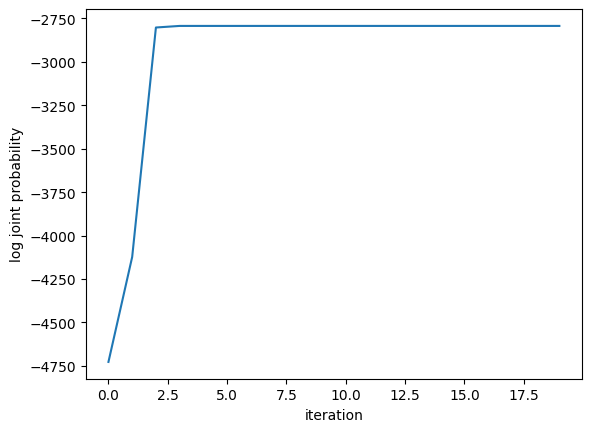

In [17]:
import matplotlib.pyplot as plt
import torch
from torch.distributions.poisson import Poisson
from torch.distributions.gamma import Gamma

def draw_data(pi, lambdas):
    """Draw data from a mixture of Poisson distributions.

    Args:
        pi: shape `(K,)` tensor of cluster probabilities
        lambdas: shape `(K,)` tensor of nonnegative rates for each cluster.
    
    Returns:
        data: shape `(N,)` tensor of counts
    """
    N = 1000
    K = pi.shape[0]
    assignments = torch.multinomial(pi, N, replacement=True)
    data = torch.poisson(lambdas[assignments])
    return data

def update_assignments(data, rates, probs):
    """Update the cluster assignments ($z$) given the data, rates, 
    and cluster probabilities.

    Args:
        data: shape `(N,)` tensor of counts
        rates: shape `(K,)` tensor of nonnegative rates for each cluster.
        probs: shape `(K,)` tensor of cluster probabilities
        
    Returns:
        assignments: shape `(N,)` tensor of integer cluster assignments
    """

    log_probs = [Poisson(rate).log_prob(data) + torch.log(prob) for rate, prob in zip(rates, probs)]

    assignments = torch.stack(log_probs).argmax(dim=0)

    return assignments

def update_rates(data, assignments, shape=1.0, inv_scale=1.0):
    """Update the rates for each cluster under a gamma prior.

    Args:
        data: shape `(N,)` tensor of counts
        assignments: shape `(N,)` tensor of integer cluster assignments
        shape: shape (aka concentration) of gamma prior. Defaults to 1.0.
        inv_scale: inverse scale (aka rate) of gamma prior. Defaults to 1.0.
        
    Returns:
        rates: shape `(K,)` tensor of updated rates for each cluster
    """
    K = torch.max(assignments) + 1
    rates = torch.zeros(K)
    for k in range(K):
        cluster_data = data[assignments == k]
        rates[k] = (shape + cluster_data.sum()-1) / (inv_scale + len(cluster_data))
    return rates
    

def log_joint(data, assignments, rates, probs, shape=1.0, inv_scale=1.0):
    """_summary_

    Args:
        data: shape `(N,)` tensor of counts
        assignments: shape `(N,)` tensor of integer cluster assignments
        rates: shape `(K,)` tensor of updated rates for each cluster
        probs: shape `(K,)` tensor of cluster probabilities
        shape: shape (aka concentration) of gamma prior. Defaults to 1.0.
        inv_scale: inverse scale (aka rate) of gamma prior. Defaults to 1.0.
        
    Returns:
        lp: scalar log joint probability under the mixture model
    """

    log_likelihood = Poisson(rates[assignments]).log_prob(data).sum()

    log_assignment_prior = torch.log(probs[assignments]).sum()

    log_rate_prior = sum(
        Gamma(shape, inv_scale).log_prob(rate)
        for rate in rates
    )

    return log_likelihood + log_assignment_prior + log_rate_prior

data = draw_data(torch.tensor([0.5, 0.5]), torch.tensor([10.0, 2.0]))

print(data)

print(Poisson(10.0).log_prob(data))


#plt.hist(data, bins=20)
    
# Run coordinate ascent for some number of iterations, starting
# with random cluster assignments
probs = torch.ones(2) / 2.0
assignments = torch.randint(0, 2, data.shape)
rates = 10 * torch.rand(2)

lps = []
for i in range(20):
    lps.append(log_joint(data, assignments, rates, probs))
    rates = update_rates(data, assignments)
    assignments = update_assignments(data, rates, probs)
    
plt.plot(lps)
plt.xlabel("iteration")
plt.ylabel("log joint probability")

print("estimated rates:", rates)